# 분산분석
### [일원분산분석]
penguins 데이터셋에서 펭귄의 종(Adelie, Chinstrap, Gentoo)에따라 몸무게(body_mass_g)에 차이가 있는지 확인하기 위해, 펭귄 세종의 몸무게 평균이 모두 같다는 귀무가설을 유의수준 5%로 검정하시오.

### [이원분산분석]
몸무게 차이가 단순히 종 때문인지, 아니면 성별의 영향도 있는지,혹은 종과 성별의 조합에서 나타나는 특이한 효과가 있는지 분석하기 위해, 종(species)과 성별(sex)을 독립변수로, 몸무게(body_mass_g)를 종속변수로 하여 이원분산분석을 수행하고 상호작용 효과를 확인하시오.

 데이터 분석 포인트

• 일원 분산 분석

– P-value를 통해 귀무가설을 기각할 수 있는가?

• 이원분산분석

– 종 별로 성별 간의 차이가 일정한지 아니면 특정 종에서만 성별 차이가 유독 크거나 작은가?

일원분산분석 결과 : p-value=3.74451e-81
-> [귀무가설 기각] 적어도 한 종의 몸무게 평균은 다릅니다!
 종에 따라 몸무게 평균에 통계적으로 유의미한 차이가 존재합니다.


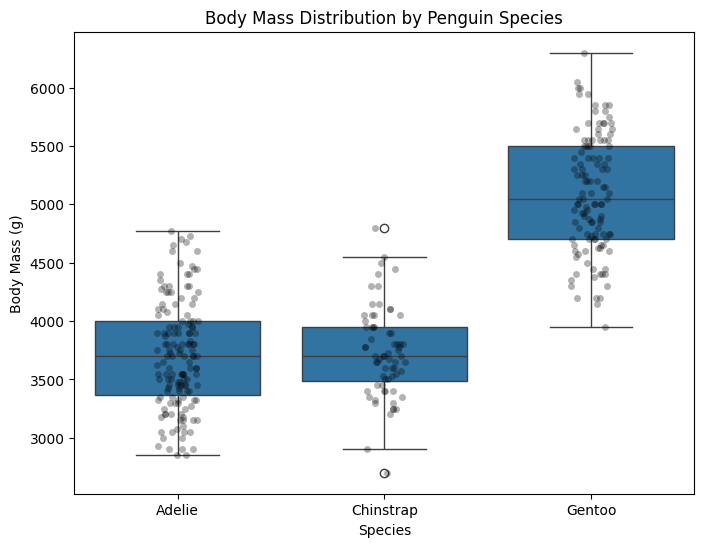

In [35]:
import seaborn as sns # 예제 데이터셋 로드 및 시각화
import pandas as pd # 데이터프레임 처리
import matplotlib.pyplot as plt # 그래프 그리기
from scipy import stats # 통계 검정 함수
from statsmodels.formula.api import ols # 회귀모형(이원분산분석용)
from statsmodels.stats.anova import anova_lm # ANOVA 표 생성

# penguins 데이터셋 로드 후 결측치(NaN) 제거
penguins = sns.load_dataset('penguins').dropna()


#  일원분산분석 : 종에 따라 몸무게 평균에 차이가 있는가?
# 종별로 몸무게(body_mass_g) 데이터를 그룹으로 분리
groups = [penguins[penguins['species'] == s]['body_mass_g']
for s in penguins['species'].unique()]

# 일원분산분석(One-way ANOVA) 실행 -> F통계량과 p-value 반환
f_stat, p_val = stats.f_oneway(*groups)
print(f'일원분산분석 결과 : p-value={p_val:.5e}')

if p_val < 0.05: # 유의수준 5%보다 작으면 귀무가설 기각
    print('-> [귀무가설 기각] 적어도 한 종의 몸무게 평균은 다릅니다!')
    print(' 종에 따라 몸무게 평균에 통계적으로 유의미한 차이가 존재합니다.')
else:
    print('-> [귀무가설 채택] 종에 따른 몸무게 평균 차이가 없습니다.')

# 종별 몸무게 분포 시각화 (박스플롯 + 개별 데이터점)
plt.figure(figsize=(8, 6))
sns.boxplot(x='species', y='body_mass_g', data=penguins)
sns.stripplot(x='species', y='body_mass_g', data=penguins,
color='black', alpha=0.3)
plt.title('Body Mass Distribution by Penguin Species')
plt.xlabel('Species'); plt.ylabel('Body Mass (g)')
plt.show()





이원분산분석 결과 :
1) 종(Species) p-value : 0.00000
2) 성별(Sex) p-value : 0.00000
3) 종*성별 상호작용 p-value : 0.00020
[종] 차이 있음 / [성별] 차이 있음 / [상호작용] 효과 있음


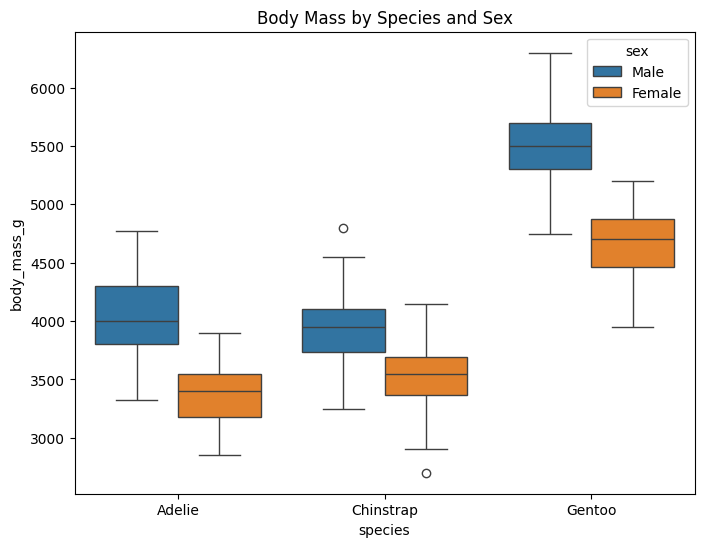

In [36]:
# 이원분산분석 : 종 + 성별 + 상호작용 효과 분석
# 종속변수 body_mass_g, 독립변수 species·sex 및 둘의 상호작용을 모형화
model = ols('body_mass_g ~ C(species) * C(sex)', data=penguins).fit()
anova_table = anova_lm(model) # 이원분산분석 표 생성

# 각 요인(종, 성별, 상호작용)의 p-value 추출
p_species = anova_table.loc['C(species)', 'PR(>F)']
p_sex = anova_table.loc['C(sex)', 'PR(>F)']
p_inter = anova_table.loc['C(species):C(sex)', 'PR(>F)']
print('이원분산분석 결과 :')
print(f'1) 종(Species) p-value : {p_species:.5f}')
print(f'2) 성별(Sex) p-value : {p_sex:.5f}')
print(f'3) 종*성별 상호작용 p-value : {p_inter:.5f}')
print('[종]' + (' 차이 있음' if p_species < 0.05 else ' 차이 없음')
+ ' / [성별]' + (' 차이 있음' if p_sex < 0.05 else ' 차이 없음')
+ ' / [상호작용]' + (' 효과 있음' if p_inter < 0.05 else ' 효과 없음'))

# 종 x 성별 조합별 몸무게 분포 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(x='species', y='body_mass_g', hue='sex', data=penguins)
plt.title('Body Mass by Species and Sex')
plt.show()

**[일원분산분석]**

· 분석 포인트 : p-value를 통해 귀무가설을 기각할 수 있는가?

일원분산분석 결과 p-value는 유의수준 0.05보다 극단적으로 작다.
 따라서 세 종의 몸무게 평균이
모두 같다는 귀무가설을 기각한다 **굵은 텍스트**.

 즉 펭귄의 종에 따라 몸무게 평균에는 통계적으로 유의미한
차이가 존재한다.

 박스플롯에서도 Gentoo의 몸무게가 약 5,000g 내외로 다른 두 종보다 뚜렷하게
무거워 이러한 차이를 시각적으로 확인할 수 있다.


**[이원분산분석]**
· 분석 포인트 : 종별로 성별 간 차이가 일정한가, 아니면 특정 종에서만 성별 차이가 유독 큰가?

종(p≈0.000), 성별(p≈0.000), 종×성별 상호작용(p≈0.0002)의 세 효과 모두 p-value가 0.05보다 작아
**유의하다.**
특히 상호작용 효과가 유의하다는 것은 **"성별에 따른 몸무게 차이의 크기가 종마다
일정하지 않다"** 는 의미이다.

 박스플롯을 보면 모든 종에서 수컷(Male)이 암컷(Female)보다 무겁지만,

그 차이의 폭이 Gentoo에서 가장 크게 나타나는 등 특정 종에서 성별 차이가 유독 크다.

 따라서
몸무게를 예측할 때는 종과 성별을 단순히 더하는 것이 아니라 두 변수의 조합까지 함께
고려해야 한다.